# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SyedaNehaBatool12/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can historical search-performance signals be used to rank content pages by their likelihood of experiencing a meaningful performance decline in a later observation window, so editors can identify which pages should be reviewed for a content refresh first?

### Decision Supported

This project supports the editorial decision: **Which pages should an editor review first for a possible content refresh?**

The unit of analysis is an anonymized content page. The output will be a ranked refresh-opportunity list, with pages receiving higher priority when the model identifies stronger evidence of future performance decline.

The primary user of the output is a content editor. Editors can review the highest-ranked pages first and decide whether to refresh, monitor, protect, or deprioritize them.

A false positive may waste editorial time on a page that did not urgently require a refresh. A false negative may leave a genuinely declining page unnoticed.

Machine learning is useful because page performance can depend on several interacting historical signals that may be difficult to combine reliably with a single manual rule. The model will be used for decision support only; it will not be presented as evidence of Google's ranking algorithm or as proof of causality.

**Task type:** Ranking / opportunity scoring  
**Primary evaluation idea:** Precision@K compared with a transparent baseline on the same validation split.

## 2. Data
### Dataset

This analysis uses the bundled public-safe dataset `data/raw/content_refresh_anonymized.csv` from the FlyRank ML Internship repository.

The dataset contains **30,000 anonymized content pages and 44 columns**. Each row represents one content item associated with an anonymized client.

The available signals include historical search visibility and engagement measures such as impressions, clicks, sessions, users, engagement, CTR, average search position, content age, freshness, content characteristics, and recent-versus-previous 30-day performance.

### Outcome and leakage control

The refresh-opportunity outcome is defined as:

`is_declining_label = 1` when `trend_direction == "down"`, otherwise `0`.

Because `trend_direction` directly defines the label, it is excluded from all model features. `trend_pct` is also excluded because it is closely derived from the same trend outcome and would leak target information into the model.

`content_id` is used only as an anonymized row identifier and is never used as a predictive feature.

`client_id` is used only for grouped train/test splitting so that pages from the same anonymized client do not appear in both training and evaluation data.

No client names, domains, URLs, private queries, credentials, or other identifying information are used or published.

### Missing data

Several descriptive fields contain missing values, including search-volume and competition attributes, text-length fields, model/provider metadata, and a small number of scroll-rate observations. Missing values will be handled inside the preprocessing pipeline rather than deleting rows unnecessarily.

The dataset contains rolling historical windows rather than explicit calendar-date columns, including 90-day aggregates and recent-versus-previous 30-day measures.

In [1]:
import pandas as pd
import numpy as np

# Public anonymized dataset from this repository
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "SyedaNehaBatool12/flyrank-ml-internship/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
})

display(summary)

Dataset loaded successfully
Rows: 30000
Columns: 44


,column,dtype,missing,missing_pct,unique_values
0,content_id,object,0,0.00,30000
1,client_id,object,0,0.00,32
2,search_volume,float64,2468,8.23,41
3,competition,float64,2468,8.23,101
4,competition_level,object,2610,8.70,3
5,cpc,float64,2468,8.23,915
6,content_type,object,0,0.00,3
7,main_intent,object,2374,7.91,4
8,word_count,float64,7699,25.66,5476
9,char_count,float64,7699,25.66,14839


In [2]:
# Look for possible date/time columns
date_like_cols = [
    c for c in df.columns
    if any(word in c.lower() for word in
           ["date", "day", "week", "month", "time"])
]

print("Possible date/time columns:")
print(date_like_cols)

# Check for fields mentioned in the capstone safety instructions
special_cols = [
    c for c in [
        "trend_direction",
        "trend_pct"
    ]
    if c in df.columns
]

print("\nPotential label-derived/leakage fields found:")
print(special_cols)

# Identify likely identifier columns
id_like_cols = [
    c for c in df.columns
    if "id" in c.lower()
]

print("\nPossible ID/grouping columns:")
print(id_like_cols)

Possible date/time columns:
['days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update']

Potential label-derived/leakage fields found:
['trend_direction', 'trend_pct']

Possible ID/grouping columns:
['content_id', 'client_id', 'provider_used']


In [3]:
# Define the target exactly as specified by the reference pipeline
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower().eq("down")
).astype(int)

label_counts = df["is_declining_label"].value_counts().sort_index()
label_pct = (
    df["is_declining_label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

label_summary = pd.DataFrame({
    "count": label_counts,
    "percent": label_pct
})

label_summary.index = ["not_declining", "declining"]

display(label_summary)

print(
    "\nDeclining base rate:",
    round(df["is_declining_label"].mean() * 100, 2),
    "%"
)

,count,percent
not_declining,13738,45.79
declining,16262,54.21



Declining base rate: 54.21 %


In [4]:
LEAKAGE_COLS = [
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

ID_GROUP_COLS = [
    "content_id",
    "client_id"
]

candidate_features = [
    c for c in df.columns
    if c not in LEAKAGE_COLS + ID_GROUP_COLS
]

numeric_features = [
    c for c in candidate_features
    if pd.api.types.is_numeric_dtype(df[c])
]

categorical_features = [
    c for c in candidate_features
    if not pd.api.types.is_numeric_dtype(df[c])
]

print("Target:")
print("is_declining_label")

print("\nExcluded leakage columns:")
print(LEAKAGE_COLS)

print("\nIdentifier / grouping columns:")
print(ID_GROUP_COLS)

print("\nNumeric candidate features:", len(numeric_features))
print(numeric_features)

print("\nCategorical candidate features:", len(categorical_features))
print(categorical_features)

Target:
is_declining_label

Excluded leakage columns:
['trend_direction', 'trend_pct', 'is_declining_label']

Identifier / grouping columns:
['content_id', 'client_id']

Numeric candidate features: 29
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical candidate features: 11
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


## 3. Methodology

### Methodology

This project treats content-refresh prioritization as a supervised ranking/classification problem.

The binary target is `is_declining_label`, defined from `trend_direction == "down"`. The model estimates the probability that a page belongs to the declining class, and those probabilities are used to rank pages for editorial review.

To prevent target leakage, `trend_direction` and `trend_pct` are never used as model features. `content_id` is used only to identify rows, while `client_id` is used only for validation grouping.

The model uses historical search, engagement, content, age, freshness and search-position signals. Highly skewed traffic-count variables are log-transformed before modeling.

Missing numeric values are converted to numeric and filled with 0. Missing categorical values are represented as `"unknown"` and categorical variables are one-hot encoded.

### Validation design

A client-level holdout is used instead of a random page-level split. Approximately 20% of anonymized clients are held out for testing. This means pages from a client in the test set cannot also appear in the training set.

Random seed: **42**.

### Baseline

The model is compared against a transparent hand-written refresh-opportunity score based on:

- search visibility,
- time since last update,
- search-position opportunity,
- and content-depth gap.

Both the baseline and learned models are evaluated on the same held-out clients.

The primary ranking metric is **Precision@50**: among the 50 pages ranked highest for review, what proportion actually carry the declining label?

The overall declining base rate is **54.21%** because evaluation uses unseen clients, the held-out test set has a lower declining rate of **39.10%**. Model and baseline ranking performance are therefore interpreted against the held-out test distribution as well as the overall dataset rate. Recent-versus-previous 30-day count fields were intentionally omitted from the learned model feature set because they could act as close proxies for the trend-derived target.

In [5]:
# Log-transform large count variables
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])

MODEL_NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

MODEL_CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

print("Numeric model features:", len(MODEL_NUMERIC_FEATURES))
print("Categorical model features:", len(MODEL_CATEGORICAL_FEATURES))

print("\nLeakage check:")
print("trend_direction used?", "trend_direction" in MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES)
print("trend_pct used?", "trend_pct" in MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES)
print("client_id used?", "client_id" in MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES)

Numeric model features: 18
Categorical model features: 8

Leakage check:
trend_direction used? False
trend_pct used? False
client_id used? False


In [6]:
RANDOM_STATE = 42

clients = df["client_id"].astype(str).drop_duplicates().to_numpy()

rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(clients)

n_test_clients = max(1, round(len(shuffled_clients) * 0.20))

test_clients = set(shuffled_clients[:n_test_clients])

test_mask = df["client_id"].astype(str).isin(test_clients)

train_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

print("Total clients:", df["client_id"].nunique())
print("Train clients:", train_df["client_id"].nunique())
print("Test clients:", test_df["client_id"].nunique())

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "\nClient overlap:",
    len(
        set(train_df["client_id"].astype(str))
        & set(test_df["client_id"].astype(str))
    )
)

print("\nTrain declining rate:", round(train_df["is_declining_label"].mean() * 100, 2), "%")
print("Test declining rate:", round(test_df["is_declining_label"].mean() * 100, 2), "%")

Total clients: 32
Train clients: 26
Test clients: 6

Train rows: 27675
Test rows: 2325

Client overlap: 0

Train declining rate: 55.48 %
Test declining rate: 39.1 %


In [7]:
# Transparent baseline used for comparison

def percentile_rank(series):
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    return values.rank(method="average", pct=True).fillna(0)

def normalize(series):
    values = (
        pd.to_numeric(series, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    minimum = values.min()
    maximum = values.max()

    if maximum == minimum:
        return pd.Series(np.zeros(len(values)), index=values.index)

    return (values - minimum) / (maximum - minimum)


# Build baseline on the full public-safe feature frame
df["visibility_score"] = percentile_rank(
    np.log1p(df["impressions_90d"])
)

df["freshness_risk_score"] = percentile_rank(
    df["days_since_last_update"]
)

df["position_opportunity_score"] = (
    (1 - normalize(df["avg_position"].clip(lower=1, upper=50)))
    * df["visibility_score"]
    * (df["avg_position"] > 0).astype(int)
)

df["depth_gap_score"] = (
    (1 - percentile_rank(df["word_count"]))
    * df["visibility_score"]
)

df["baseline_refresh_score"] = (
    0.40 * df["visibility_score"]
    + 0.30 * df["freshness_risk_score"]
    + 0.25 * df["position_opportunity_score"]
    + 0.05 * df["depth_gap_score"]
).clip(0, 1)

print("Baseline created successfully.")
display(
    df[
        [
            "visibility_score",
            "freshness_risk_score",
            "position_opportunity_score",
            "depth_gap_score",
            "baseline_refresh_score",
        ]
    ].describe()
)

Baseline created successfully.


,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score,baseline_refresh_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.500017,0.500017,0.347342,0.241066,0.448901
std,0.288669,0.276232,0.260751,0.210313,0.215599
min,0.017933,0.001983,0.000000,0.000000,0.007958
25%,0.249817,0.336000,0.125569,0.063812,0.281418
50%,0.499933,0.336000,0.303294,0.189800,0.442861
75%,0.750012,0.843200,0.542914,0.361401,0.623330
max,1.000000,0.999967,0.991539,0.871667,0.941189


In [8]:
def precision_at_k(y_true, scores, k):
    temp = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    top_k = (
        temp.sort_values("score", ascending=False)
        .head(min(k, len(temp)))
    )

    return float(top_k["y_true"].mean())


# Evaluate baseline only on held-out clients
baseline_test_scores = df.loc[
    test_df.index, "baseline_refresh_score"
]

y_test = test_df["is_declining_label"]

baseline_p20 = precision_at_k(
    y_test, baseline_test_scores, 20
)

baseline_p50 = precision_at_k(
    y_test, baseline_test_scores, 50
)

baseline_p100 = precision_at_k(
    y_test, baseline_test_scores, 100
)

test_base_rate = y_test.mean()

baseline_results = pd.DataFrame({
    "Metric": [
        "Test declining base rate",
        "Baseline Precision@20",
        "Baseline Precision@50",
        "Baseline Precision@100",
    ],
    "Value": [
        test_base_rate,
        baseline_p20,
        baseline_p50,
        baseline_p100,
    ]
})

display(baseline_results.style.format({"Value": "{:.3f}"}))

,Metric,Value
0,Test declining base rate,0.391
1,Baseline Precision@20,0.150
2,Baseline Precision@50,0.240
3,Baseline Precision@100,0.360


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -------------------------
# Training / test matrices
# -------------------------

X_train = train_df[
    MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES
].copy()

X_test = test_df[
    MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES
].copy()

y_train = train_df["is_declining_label"].copy()
y_test = test_df["is_declining_label"].copy()


# -------------------------
# Preprocessing
# -------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="constant", fill_value="unknown")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        MODEL_NUMERIC_FEATURES
    ),
    (
        "categorical",
        categorical_pipeline,
        MODEL_CATEGORICAL_FEATURES
    )
])


# -------------------------
# Models
# -------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}


trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

print("\nAll models trained.")

Training Logistic Regression...
Logistic Regression trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Random Forest...
Random Forest trained successfully.

All models trained.


## 4. Results (vs baseline)

### Results

Evaluation was performed on **2,325 pages from 6 completely held-out anonymized clients**. No client appeared in both the training and test sets. The declining-label base rate in the held-out test set was **39.1%**.

The transparent baseline performed poorly at the top of the ranking, achieving **24.0% Precision@50**, which is below the held-out base rate.

Logistic Regression improved overall discrimination to a ROC-AUC of **0.703**, but its Precision@50 was only **34.0%**.

The Decision Tree performed substantially better, reaching a ROC-AUC of **0.740** and **56.0% Precision@50**.

The **Random Forest was the strongest model across the main ranking and discrimination metrics**. It achieved:

- **ROC-AUC:** 0.756
- **PR-AUC:** 0.647
- **Precision@20:** 85.0%
- **Precision@50:** 80.0%
- **Precision@100:** 81.0%
- **Lift@50:** 2.05×

At Precision@50, this means that approximately **40 of the 50 pages ranked highest by the Random Forest carried the declining label**.

Compared with the hand-written baseline, Random Forest improved Precision@50 from **24% to 80%**, an absolute improvement of **56 percentage points**.

The result suggests that combining historical search, engagement, content, freshness, and position signals can produce a substantially more useful editorial review queue than the transparent baseline on these held-out clients. These results are interpreted as **decision-support evidence**, not as proof of causality or of Google's ranking algorithm.

In [10]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

def evaluate_scores(y_true, scores, name):

    base_rate = float(np.mean(y_true))

    p20 = precision_at_k(y_true, scores, 20)
    p50 = precision_at_k(y_true, scores, 50)
    p100 = precision_at_k(y_true, scores, 100)

    auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    lift50 = (
        p50 / base_rate
        if base_rate > 0
        else np.nan
    )

    return {
        "Model": name,
        "ROC-AUC": auc,
        "PR-AUC": pr_auc,
        "Precision@20": p20,
        "Precision@50": p50,
        "Precision@100": p100,
        "Lift@50": lift50
    }


results = []

# Baseline
results.append(
    evaluate_scores(
        y_test,
        baseline_test_scores,
        "Baseline"
    )
)

# ML models
model_test_scores = {}

for name, pipeline in trained_models.items():

    scores = pipeline.predict_proba(X_test)[:, 1]

    model_test_scores[name] = scores

    results.append(
        evaluate_scores(
            y_test,
            scores,
            name
        )
    )


results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}",
        "Precision@20": "{:.3f}",
        "Precision@50": "{:.3f}",
        "Precision@100": "{:.3f}",
        "Lift@50": "{:.2f}x"
    })
)

print(
    "Held-out declining base rate:",
    round(y_test.mean(), 3)
)

,Model,ROC-AUC,PR-AUC,Precision@20,Precision@50,Precision@100,Lift@50
0,Baseline,0.627,0.468,0.150,0.240,0.360,0.61x
1,Logistic Regression,0.703,0.521,0.350,0.340,0.420,0.87x
2,Decision Tree,0.740,0.570,0.600,0.560,0.560,1.43x
3,Random Forest,0.756,0.647,0.850,0.800,0.810,2.05x


Held-out declining base rate: 0.391


In [11]:
# Feature importance from the selected Random Forest model

rf_pipeline = trained_models["Random Forest"]

rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

,feature,importance
0,numeric__days_with_impressions,0.118385
1,numeric__avg_position,0.117830
2,numeric__log_impressions_90d,0.111834
3,numeric__content_age_days,0.084180
4,numeric__char_count,0.042343
5,numeric__word_count,0.041177
6,numeric__ctr,0.038801
7,numeric__scroll_rate,0.037434
8,numeric__log_clicks_90d,0.036639
9,numeric__days_with_sessions,0.036330


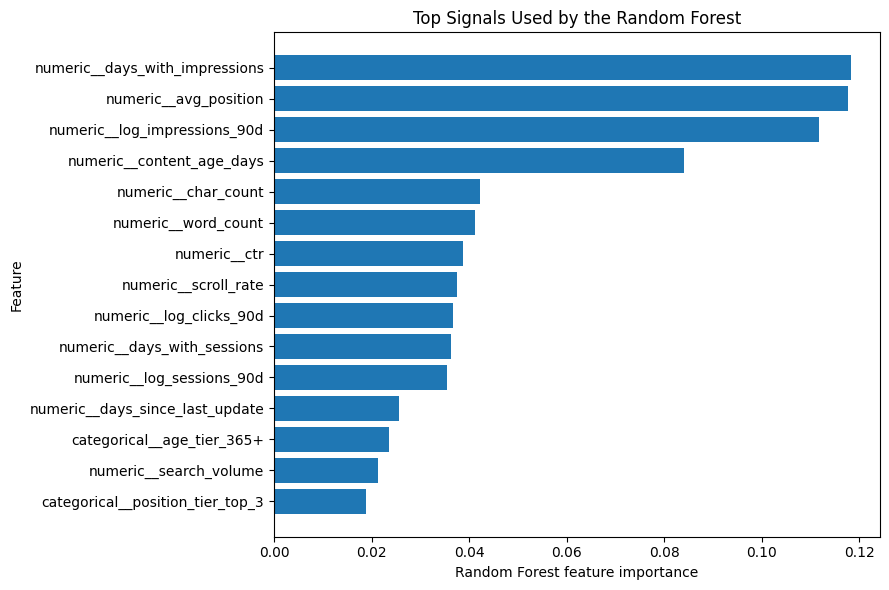

In [12]:
import matplotlib.pyplot as plt

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Top Signals Used by the Random Forest")

plt.tight_layout()
plt.show()

### Interpretation

The Random Forest relied most heavily on signals related to search visibility, ranking position, traffic persistence, and content age.

The three strongest individual features were `days_with_impressions`, `avg_position`, and log-transformed 90-day impressions. `content_age_days` was also substantially important. Secondary signals included content length, CTR, scroll rate, clicks, sessions, and time since the last update.

This suggests that the model's ranking is not driven by one isolated feature. Instead, it combines visibility, search position, content maturity, engagement, and traffic history to identify pages associated with decline.

Feature importance is interpreted only as model usage, not causal effect. A high importance value does not show whether increasing a feature raises or lowers decline risk, and it does not prove that the feature causes search-performance changes.

## 5. Limitations

This analysis is observational and should be used for decision support rather than causal conclusions.

The target is derived from an observed trend label in the supplied dataset. The model therefore learns associations with that label; it does not prove why a page declined or demonstrate how Google's ranking algorithm works.

The evaluation uses a client-level holdout, which is stronger than a random page split, but the held-out set contains only six anonymized clients. Performance may differ for future clients, different content portfolios, or later time periods.

The test-set decline rate (39.1%) is also meaningfully lower than the training-set rate (55.5%), showing that client populations can differ substantially.

Random Forest feature importance indicates which signals the model used but does not provide the direction of each relationship or establish causality.

Some source fields contain missing values and are handled through preprocessing. In addition, recent-versus-previous 30-day trend-like fields and explicit trend-derived fields were deliberately excluded to reduce leakage risk.

Finally, a high model score should trigger editorial review, not an automatic content rewrite. Editors should use page context, business value, search intent, and content quality before taking action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [13]:
# Build a ranked editorial review queue from the selected model

rf_scores = model_test_scores["Random Forest"]

recommendations = test_df[
    [
        "content_id",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "engagement_rate",
        "is_declining_label"
    ]
].copy()

recommendations["refresh_risk_score"] = rf_scores

recommendations = (
    recommendations
    .sort_values("refresh_risk_score", ascending=False)
    .reset_index(drop=True)
)

recommendations["rank"] = np.arange(1, len(recommendations) + 1)

# Convert rank into a simple editorial action
recommendations["action"] = pd.cut(
    recommendations["rank"],
    bins=[0, 50, 200, 500, np.inf],
    labels=[
        "Review first",
        "Review soon",
        "Monitor",
        "Lower priority"
    ]
)

display(
    recommendations[
        [
            "rank",
            "refresh_risk_score",
            "action",
            "content_age_days",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,rank,refresh_risk_score,action,content_age_days,days_since_last_update,impressions_90d,ctr,avg_position
0,1,0.848259,Review first,140,8,767,0.00,3.0
1,2,0.831764,Review first,148,8,4908,0.06,29.1
2,3,0.828755,Review first,140,8,405,0.00,10.6
3,4,0.825484,Review first,140,8,682,0.15,15.1
4,5,0.814914,Review first,140,8,868,0.00,13.7
5,6,0.814766,Review first,140,8,337,0.00,13.9
6,7,0.806290,Review first,140,8,711,0.00,41.7
7,8,0.805480,Review first,112,20,369,0.00,21.8
8,9,0.805138,Review first,125,20,2305,0.00,12.3
9,10,0.803285,Review first,117,20,312,0.00,12.8


In [14]:
action_summary = (
    recommendations
    .groupby("action", observed=False)
    .agg(
        pages=("rank", "count"),
        observed_decline_rate=("is_declining_label", "mean"),
        average_model_score=("refresh_risk_score", "mean")
    )
    .reset_index()
)

display(
    action_summary.style.format({
        "observed_decline_rate": "{:.1%}",
        "average_model_score": "{:.3f}"
    })
)

,action,pages,observed_decline_rate,average_model_score
0,Review first,50,80.0%,0.792
1,Review soon,150,76.0%,0.754
2,Monitor,300,64.0%,0.715
3,Lower priority,1825,30.8%,0.436


### Ranked Recommendations

The selected Random Forest model was used to rank all 2,325 pages in the held-out client set by predicted decline risk.

The ranked queue was converted into four practical editorial action groups:

- **Review first:** the top 50 pages. This group had an observed decline rate of **80.0%** and an average model score of **0.792**.
- **Review soon:** ranks 51–200. These 150 pages had an observed decline rate of **76.0%** and an average score of **0.754**.
- **Monitor:** ranks 201–500. These 300 pages had an observed decline rate of **64.0%** and an average score of **0.715**.
- **Lower priority:** the remaining 1,825 pages. This group had an observed decline rate of **30.8%** and an average score of **0.436**.

The recommended operational use is to start editorial review with the highest-ranked pages rather than treating all pages equally. A high model score should trigger human review, not an automatic rewrite.

Editors should consider search intent, business value, content quality, page context, and current strategic priorities before deciding whether a page should actually be refreshed.

The action thresholds used here are practical queue-size choices rather than statistically optimized cutoffs. They are intended to demonstrate how the ranking can support an editorial workflow and can be adjusted to match available review capacity.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [15]:
import os
import matplotlib.pyplot as plt

ARTIFACT_DIR = "/content/capstone_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Artifacts will be saved to:")
print(ARTIFACT_DIR)

Artifacts will be saved to:
/content/capstone_artifacts


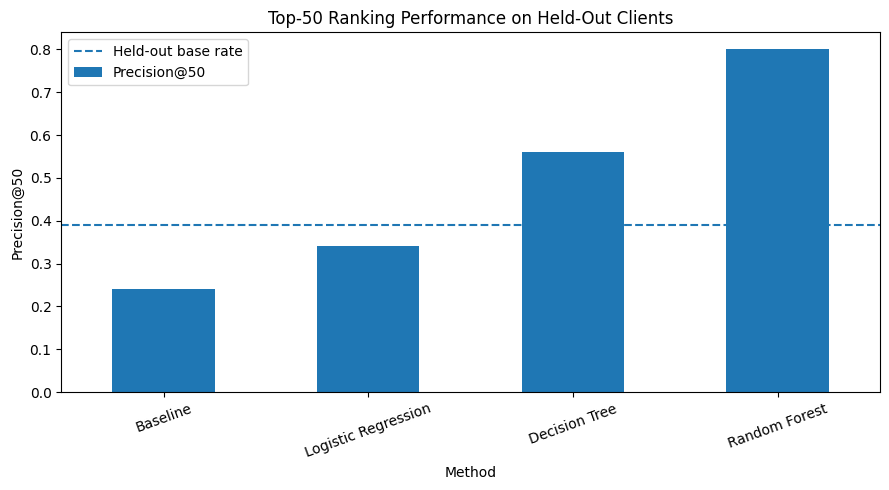

/content/capstone_artifacts/model_precision_at_50.png


In [16]:
plot_df = results_df.set_index("Model")

plt.figure(figsize=(9, 5))

plot_df["Precision@50"].plot(kind="bar")

plt.axhline(
    y=float(y_test.mean()),
    linestyle="--",
    label="Held-out base rate"
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Top-50 Ranking Performance on Held-Out Clients")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

model_chart_path = os.path.join(
    ARTIFACT_DIR,
    "model_precision_at_50.png"
)

plt.savefig(
    model_chart_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(model_chart_path)

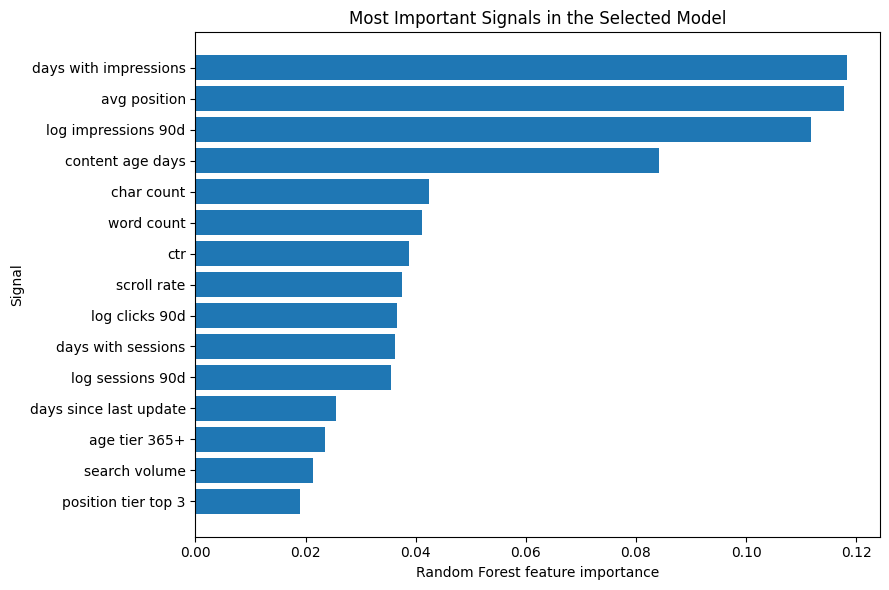

/content/capstone_artifacts/feature_importance.png


In [17]:
clean_feature_importance = feature_importance_df.copy()

clean_feature_importance["feature"] = (
    clean_feature_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ")
)

top_features_clean = (
    clean_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features_clean["feature"],
    top_features_clean["importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Signal")
plt.title("Most Important Signals in the Selected Model")

plt.tight_layout()

feature_chart_path = os.path.join(
    ARTIFACT_DIR,
    "feature_importance.png"
)

plt.savefig(
    feature_chart_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(feature_chart_path)

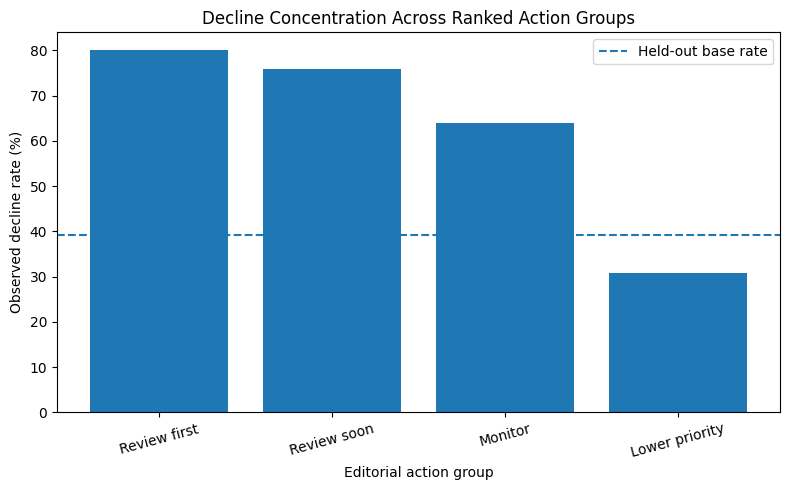

/content/capstone_artifacts/action_group_decline_rate.png


In [18]:
action_plot = action_summary.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    action_plot["action"].astype(str),
    action_plot["observed_decline_rate"] * 100
)

plt.axhline(
    y=float(y_test.mean() * 100),
    linestyle="--",
    label="Held-out base rate"
)

plt.ylabel("Observed decline rate (%)")
plt.xlabel("Editorial action group")
plt.title("Decline Concentration Across Ranked Action Groups")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()

action_chart_path = os.path.join(
    ARTIFACT_DIR,
    "action_group_decline_rate.png"
)

plt.savefig(
    action_chart_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(action_chart_path)

In [19]:
# Save model results
results_df.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        "model_results.csv"
    ),
    index=False
)

# Save action summary
action_summary.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        "action_summary.csv"
    ),
    index=False
)

# Public-safe ranked sample: no IDs
public_ranked_sample = recommendations[
    [
        "rank",
        "refresh_risk_score",
        "action",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "avg_position"
    ]
].head(50)

public_ranked_sample.to_csv(
    os.path.join(
        ARTIFACT_DIR,
        "top50_public_safe_ranked_sample.csv"
    ),
    index=False
)

print("Saved artifacts:")
for filename in sorted(os.listdir(ARTIFACT_DIR)):
    print("-", filename)

Saved artifacts:
- action_group_decline_rate.png
- action_summary.csv
- feature_importance.png
- model_precision_at_50.png
- model_results.csv
- top50_public_safe_ranked_sample.csv


### Paper Artifacts

The deployed research paper will embed:

1. **Model comparison chart** — Precision@50 for the baseline and three learned models, with the held-out decline rate shown for context.
2. **Feature importance chart** — the 15 most important signals used by the selected Random Forest.
3. **Action-group chart** — observed decline concentration across the Review First, Review Soon, Monitor, and Lower Priority queues.
4. **Model results table** — ROC-AUC, PR-AUC, Precision@20, Precision@50, Precision@100, and Lift@50.
5. **Action summary table** — page count, observed decline rate, and average model score for each editorial action group.

Only public-safe aggregated results and anonymized feature descriptions are included. Client identifiers and content identifiers are not exposed in the deployed paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — Closing Deliverables
### 1. Five-Minute Demo Outline

**0:00–0:45 — Problem**
Content teams cannot manually review every page equally. This project asks whether historical search-performance and content signals can help rank pages that deserve content-refresh review first.

**0:45–1:30 — Data and Safety**
The analysis uses 30,000 anonymized content pages from the FlyRank ML Internship dataset. Client and content identifiers were excluded from model features, while `trend_direction` and `trend_pct` were excluded to prevent target leakage.

**1:30–2:30 — Method**
A client-level holdout was used so that pages from the same client could not appear in both training and testing. A transparent baseline was compared with Logistic Regression, Decision Tree, and Random Forest models.

**2:30–3:30 — Results**
Random Forest performed best on the six held-out clients, achieving ROC-AUC 0.756, PR-AUC 0.647, and Precision@50 of 80%. This compares with 24% Precision@50 for the baseline and a 39.1% decline rate in the held-out set.

**3:30–4:20 — Interpretation**
The most important model signals included days with impressions, average search position, 90-day impressions, and content age. These are associations used for ranking and should not be interpreted as causal ranking factors.

**4:20–5:00 — Action**
The model converts predictions into an editorial queue: Review First, Review Soon, Monitor, and Lower Priority. The top 50 pages had an observed decline rate of 80%, helping editors focus limited review capacity where it is most likely to be useful.
### 2. Social Post

I completed my Machine Learning capstone on search discoverability and content-refresh prioritization using the FlyRank ML Internship dataset.

I built and evaluated a client-safe ranking pipeline comparing a transparent baseline, Logistic Regression, Decision Tree, and Random Forest. On completely held-out clients, the selected Random Forest achieved 80% Precision@50 and 2.05× lift over the held-out decline base rate.

The project focuses on practical decision support: ranking which content pages editors should review first while maintaining leakage controls, anonymization, and honest non-causal interpretation.
### 3. Employer-Facing Summary

I built an end-to-end machine learning pipeline that ranks content pages for editorial refresh review using anonymized historical search, engagement, freshness, and content signals. I designed client-level validation and explicit leakage controls, compared the learned models against a transparent baseline, and achieved 80% Precision@50 with the selected Random Forest on held-out clients. The final output translates model predictions into an actionable editorial priority queue rather than stopping at model metrics.

In [20]:
import shutil

shutil.make_archive(
    "/content/capstone_artifacts",
    "zip",
    "/content/capstone_artifacts"
)

print("ZIP created: /content/capstone_artifacts.zip")

ZIP created: /content/capstone_artifacts.zip
